# 07 — Debris-Flow Runout

**Short course:** *Geomorphological Hazards of Slopes* &nbsp;•&nbsp; University of Silesia in Sosnoviec &nbsp;•&nbsp; 2 ECTS

*Lecturer: Ola Fredin*

---

A debris flow is a saturated mixture of water, sediment, and organic debris moving rapidly down a steep channel. Unlike the rockfall of notebook 06, a debris flow moves as a *single mass* and can **grow as it travels** by entraining channel-bed material. A 1000 m³ initiation can deliver 20 000 m³ to the fan apex. This makes debris-flow runout the single most destructive process in alpine valleys worldwide — and the hardest to forecast quantitatively.

We will not solve the depth-averaged Saint-Venant equations here (that is what RAMMS and FLO-2D are for). Instead, we cover the two empirical workhorses of debris-flow hazard assessment: **volume–runout scaling** (Rickenmann 1999, Iverson 1997) and the **mobility ratio H/L** (Corominas 1996). These are zero-parameter or one-parameter estimates of runout from quantities — initiation volume, source elevation — that *can* be estimated from a DEM and a regional inventory.


## About this notebook

**Learning objectives.** By the end of this notebook the student will be able to:

1. Sketch the three zones of a debris-flow path (initiation, transport, deposition) and link initiation to the shallow-landslide mechanics of notebooks 04–05.
2. Apply the volume–runout scaling law $L = k\,V^{1/3}$ and the Corominas mobility law $\log(H/L) = a\,\log V + b$.
3. Build an α-line / β-line analysis on a longitudinal channel profile.
4. Run a Monte-Carlo runout simulation for an event whose initiation volume is uncertain.
5. Discuss the limitations of empirical scaling laws and where dynamic models (Voellmy, RAMMS) are needed instead.

**Prerequisites.** Notebooks 04 (infinite slope) and 05 (rainfall triggers) for initiation mechanics; notebook 06 (rockfall) for the runout-statistics workflow.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from style import apply_style, COLORS, save_figure
apply_style()

from ipywidgets import interact, FloatSlider, FloatLogSlider

np.random.seed(7)  # reproducible figures


## 1. Anatomy of a debris-flow path

Every debris flow has the same three-zone anatomy:

- **Initiation zone.** A shallow translational slide on a saturated hollow (notebooks 04, 05) or a headwall failure feeding a steep gully. Slopes are 25–45°; initiation volumes are 10³–10⁵ m³.
- **Transport zone.** A pre-existing channel, often a debris-flow-cut gorge, with slope 10–30°. The flow accelerates, *entrains bed material* (multiplying volume by 2–10× over several km), and may overtop the channel into adjacent ones.
- **Deposition zone.** The fan, with slope < 10–12°. The flow spreads laterally, decelerates, and deposits its load. Most fan settlements sit here — including a great many Tatra and Carpathian villages.

The deposition zone is where people live. The empirical scaling laws below answer the central hazard question: **for a given initiation volume in the transport zone, how far down the fan will the flow reach?**

The figure below sketches all three zones along a single longitudinal profile. The channel line is colour-coded red, orange, green from source to toe; the corresponding slope-angle ranges are shown in the bars at the top. The features that drive the empirical scaling laws in §2–§4 are all visible: the shallow-slide release at the top, the entrainment arrows in the middle (volume multiplies by 2–10× as bed material is swept up), and the spreading fan at the bottom — with a few houses to remind you who lives in the runout zone.

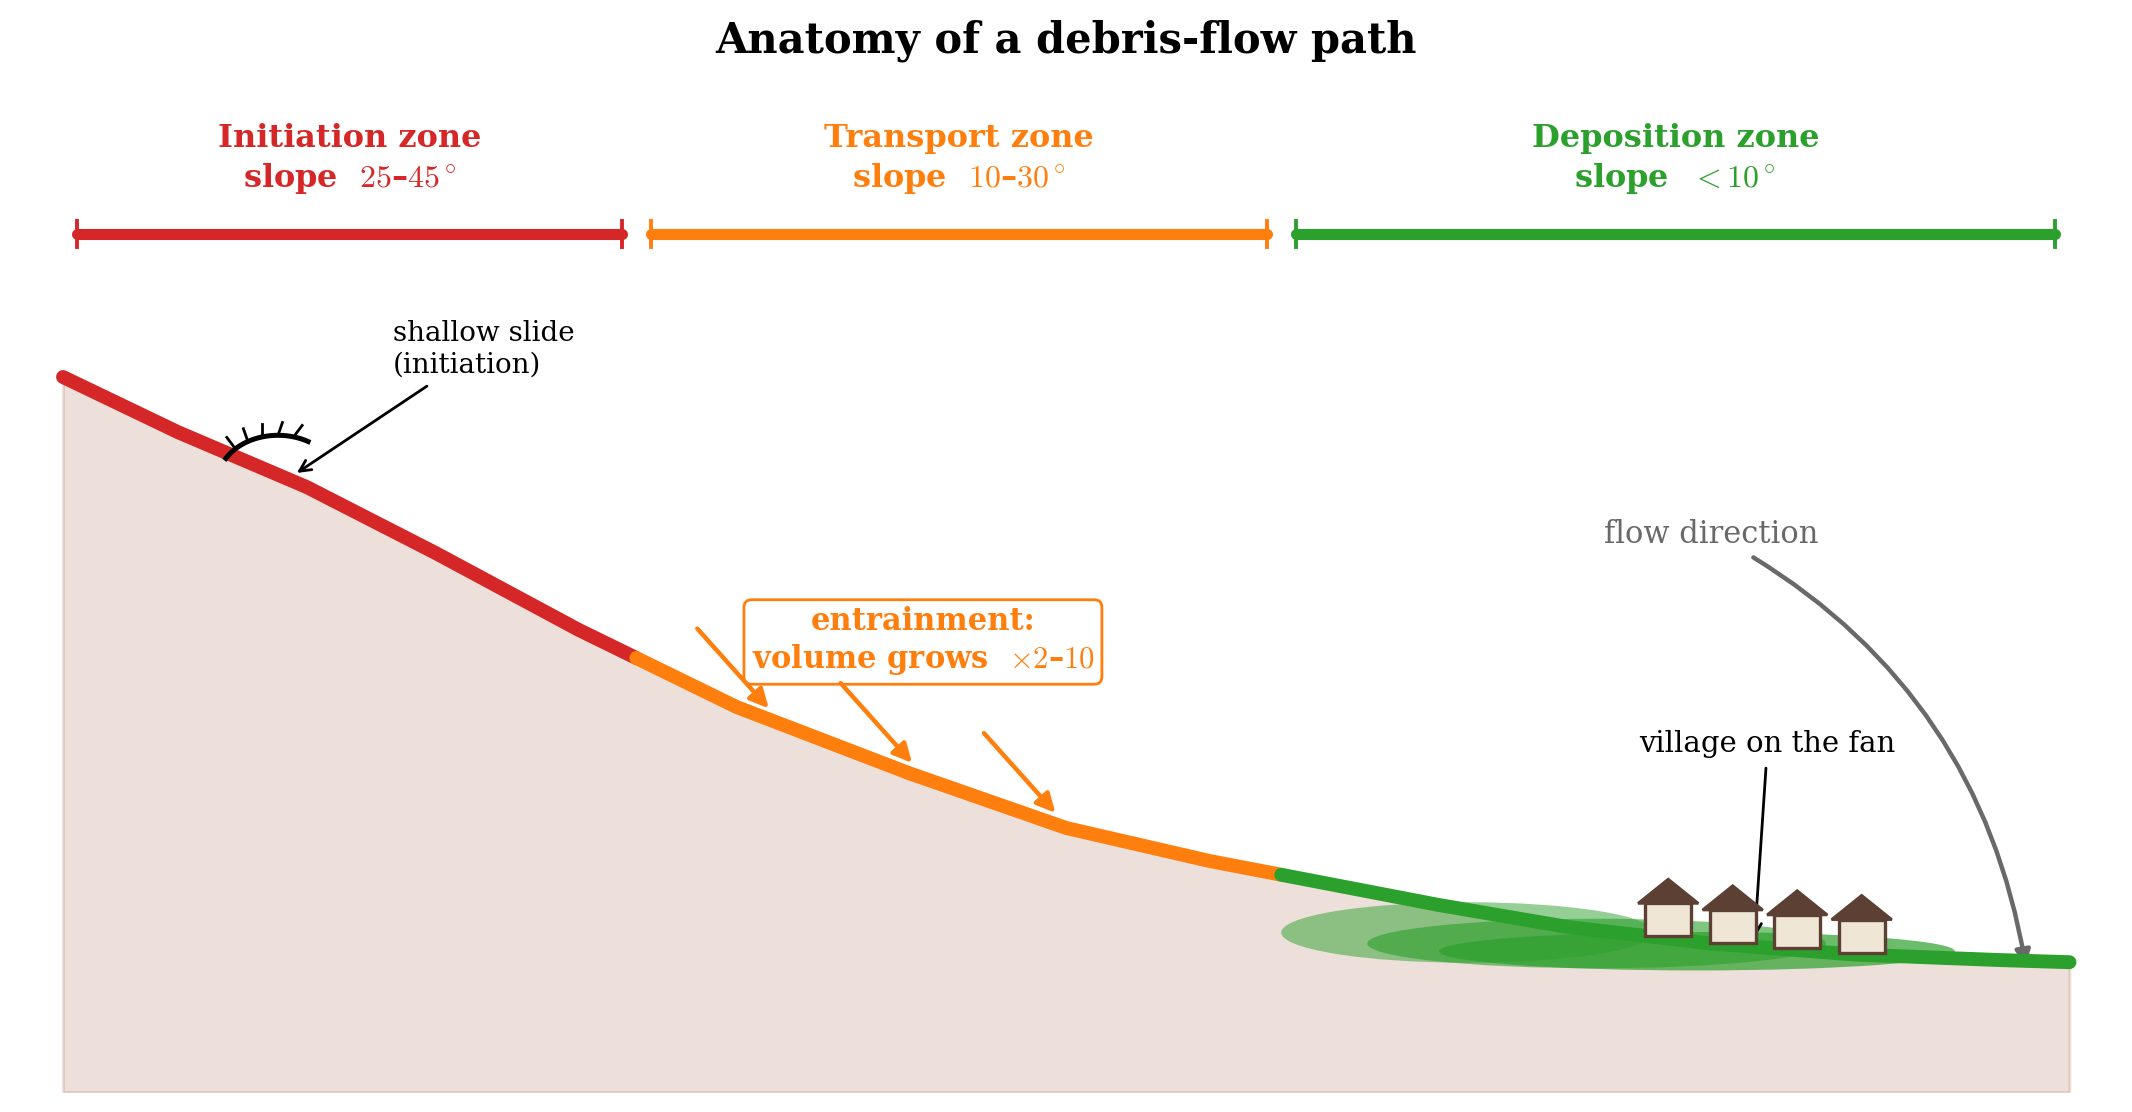

In [1]:
# Debris-flow anatomy cartoon for §1.
# A single longitudinal-profile panel showing the three zones along the path:
# initiation (red, 25–45°), transport (orange, 10–30°), deposition (green, <10°).
# Features: shallow-slide release, entrainment arrows, fan lobes, village.
# Output: figures/debris_flow_anatomy.{svg,png}
from matplotlib.patches import Polygon, Ellipse

fig, ax = plt.subplots(figsize=(13.5, 6.5))

# Channel longitudinal profile
cx = np.array([0.0, 0.8, 1.7, 2.6, 3.6, 4.7, 5.9, 7.0, 8.0, 8.8,
               9.6, 10.5, 11.5, 12.5, 13.5, 14.0])
cy = np.array([6.0, 5.5, 5.0, 4.4, 3.7, 3.0, 2.4, 1.9, 1.6, 1.4,
               1.2, 1.0, 0.85, 0.75, 0.70, 0.68])

INIT_END  = 4.0
TRANS_END = 8.5

# Mountain mass below the channel
ax.fill_between(cx, cy, -0.5, color=COLORS["soil"], alpha=0.18, zorder=1)
ax.plot(cx, cy, color=COLORS["soil"], lw=2.0, zorder=2)

ZONE_COLORS = {"init": COLORS["fail"], "trans": COLORS["accent"], "dep": COLORS["safe"]}

def _segment(xa, xb, color):
    mask = (cx >= xa - 1e-9) & (cx <= xb + 1e-9)
    xs, ys = cx[mask].copy(), cy[mask].copy()
    if xa not in cx:
        xs = np.concatenate([[xa], xs]); ys = np.concatenate([[float(np.interp(xa, cx, cy))], ys])
    if xb not in cx:
        xs = np.concatenate([xs, [xb]]); ys = np.concatenate([ys, [float(np.interp(xb, cx, cy))]])
    ax.plot(xs, ys, color=color, lw=5.0, solid_capstyle="round", zorder=4)

_segment(0.0,        INIT_END,  ZONE_COLORS["init"])
_segment(INIT_END,   TRANS_END, ZONE_COLORS["trans"])
_segment(TRANS_END,  cx[-1],    ZONE_COLORS["dep"])

# Initiation feature: arcuate scarp + hatch + label
scarp_cx, scarp_cy = 1.5, 5.05
ang = np.linspace(np.radians(150), np.radians(60), 40)
scarp_r = 0.42
ax.plot(scarp_cx + scarp_r * np.cos(ang),
        scarp_cy + scarp_r * np.sin(ang),
        color="black", lw=1.8, zorder=5)
for theta in np.linspace(np.radians(75), np.radians(135), 5):
    tx = scarp_cx + scarp_r * np.cos(theta); ty = scarp_cy + scarp_r * np.sin(theta)
    ax.plot([tx, tx + 0.12 * np.cos(theta - np.radians(15))],
            [ty, ty + 0.12 * np.sin(theta - np.radians(15))],
            color="black", lw=1.0, zorder=5)
ax.annotate("shallow slide\n(initiation)",
            xy=(scarp_cx + 0.1, scarp_cy + 0.05),
            xytext=(scarp_cx + 0.8, scarp_cy + 1.0),
            fontsize=10, color="black", ha="left",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0))

# Transport feature: entrainment arrows + label
for x_arr in [5.0, 6.0, 7.0]:
    y_ch = float(np.interp(x_arr, cx, cy))
    ax.annotate("", xy=(x_arr - 0.05, y_ch + 0.10),
                xytext=(x_arr - 0.6, y_ch + 0.9),
                arrowprops=dict(arrowstyle="-|>", color=COLORS["accent"],
                                lw=1.6, mutation_scale=14), zorder=5)
ax.text(6.0, 3.6, "entrainment:\nvolume grows  $\\times 2$–$10$",
        fontsize=11, ha="center", va="center", color=COLORS["accent"],
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                  edgecolor=COLORS["accent"], lw=1.0))

# Deposition: fan lobes
for s in [dict(cx=9.8, cy=0.95, w=2.6, h=0.55, alpha=0.50),
          dict(cx=10.7, cy=0.85, w=3.2, h=0.45, alpha=0.60),
          dict(cx=11.4, cy=0.78, w=3.6, h=0.35, alpha=0.70)]:
    ax.add_patch(Ellipse((s["cx"], s["cy"]), s["w"], s["h"],
                         facecolor=COLORS["safe"], alpha=s["alpha"],
                         edgecolor="none", zorder=3))

# Village (small houses on the fan)
def _house(ax, x, y, w=0.32, h=0.30, color="#5C4033"):
    ax.add_patch(plt.Rectangle((x - w/2, y), w, h,
                                facecolor="#F0E6D6", edgecolor=color, lw=1.2, zorder=6))
    roof = [(x - w/2 - 0.05, y + h), (x, y + h + 0.22), (x + w/2 + 0.05, y + h)]
    ax.add_patch(Polygon(roof, facecolor=color, edgecolor=color, lw=1.0, zorder=7))

for vx in [11.2, 11.65, 12.1, 12.55]:
    vy = float(np.interp(vx, cx, cy)) + 0.02
    _house(ax, vx, vy)
ax.annotate("village on the fan",
            xy=(11.8, 0.85), xytext=(11.0, 2.6),
            fontsize=10.5, color="black", ha="left",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0))

# Zone labels along the top
zones_meta = [
    ("Initiation zone",  0.0,       INIT_END,  r"slope  $25$–$45^\circ$",  ZONE_COLORS["init"]),
    ("Transport zone",   INIT_END,  TRANS_END, r"slope  $10$–$30^\circ$",  ZONE_COLORS["trans"]),
    ("Deposition zone",  TRANS_END, cx[-1],    r"slope  $< 10^\circ$",     ZONE_COLORS["dep"]),
]
top_y = 7.3
for label, x0, x1, slope_label, color in zones_meta:
    ax.plot([x0 + 0.1, x1 - 0.1], [top_y, top_y],
            color=color, lw=4.0, solid_capstyle="round")
    for xe in (x0 + 0.1, x1 - 0.1):
        ax.plot([xe, xe], [top_y - 0.12, top_y + 0.12], color=color, lw=1.4)
    ax.text((x0 + x1) / 2, top_y + 0.35,
            f"{label}\n{slope_label}",
            ha="center", va="bottom",
            fontsize=11.5, fontweight="bold", color=color, linespacing=1.3)

# Flow direction
ax.annotate("flow direction",
            xy=(13.7, 0.6), xytext=(11.5, 4.5),
            fontsize=11, color="dimgray", ha="center",
            arrowprops=dict(arrowstyle="-|>", color="dimgray", lw=1.6,
                            connectionstyle="arc3,rad=-0.25"))

ax.set_xlim(-0.3, 14.3); ax.set_ylim(-0.5, 8.6)
ax.set_aspect("auto"); ax.grid(False); ax.axis("off")
ax.set_title("Anatomy of a debris-flow path", pad=14, fontsize=15, fontweight="bold")
save_figure(fig, "debris_flow_anatomy")
plt.show()


## 2. Volume–runout scaling

Iverson (1997) and Rickenmann (1999) independently observed that debris-flow runout length $L$ from source to deposit toe scales with initiation volume $V$ as

$$
\boxed{\;L \;=\; k\,V^{1/3}\;}
\qquad (1)
$$

with $L$ in metres, $V$ in m³, and a mobility coefficient $k$ that depends on flow type:

| flow type | $k$ |
|---|---|
| Lahars (volcanic mudflows) | 100–150 |
| Mountain debris flows | 30–80 |
| Hyper-concentrated flows | 15–30 |

The $V^{1/3}$ form has a simple physical interpretation: it is what you get if a flow of fixed *shape* scales geometrically. Real flows depart from it because of entrainment (the effective $V$ at the deposit toe is larger than at initiation) and channel confinement (lateral spreading shortens runout), but the scaling captures the dominant volume effect across seven orders of magnitude.


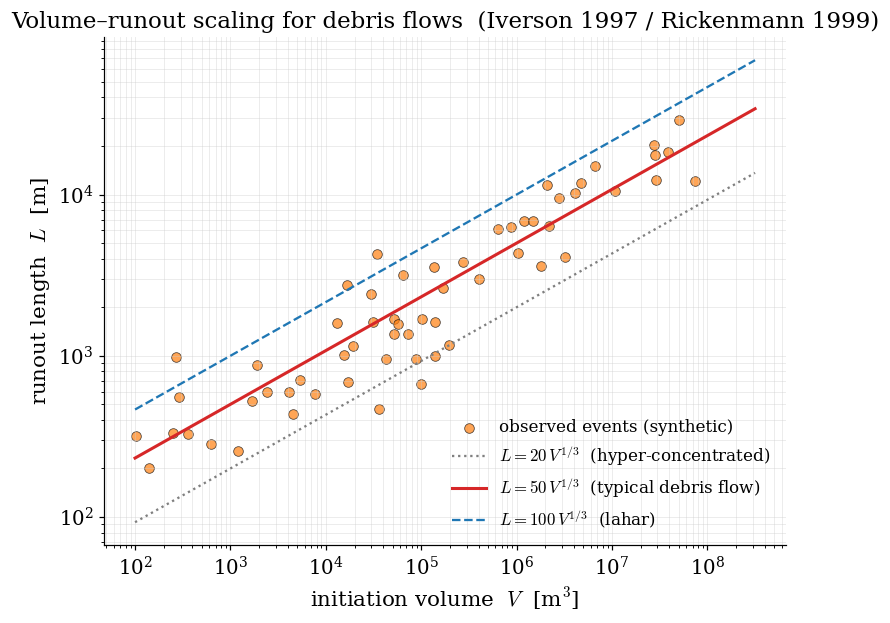

In [8]:
# Synthetic global compilation: log-uniform volumes with log-normal scatter around the
# Iverson scaling. Constants chosen so the cloud resembles published compilations
# (Rickenmann 1999 Fig. 2; Iverson 1997 Fig. 6).
N = 60
V_obs   = 10**np.random.uniform(2.0, 8.0, N)              # 100 m^3 .. 1e8 m^3
k_obs   = np.random.normal(50.0, 15.0, N).clip(15.0, 130.0)  # heterogeneous mobility
noise   = np.random.normal(0.0, 0.20, N)                  # log10-scale scatter
L_obs   = k_obs * V_obs**(1.0/3.0) * 10**noise

# Theoretical lines
V_grid = np.logspace(2, 8.5, 200)
L_iverson_low   = 20.0  * V_grid**(1.0/3.0)
L_iverson_mid   = 50.0  * V_grid**(1.0/3.0)
L_iverson_high  = 100.0 * V_grid**(1.0/3.0)

fig, ax = plt.subplots(figsize=(8.0, 6.0))
ax.scatter(V_obs, L_obs, s=40, color=COLORS["accent"], alpha=0.7,
           edgecolor="black", linewidth=0.5, label="observed events (synthetic)")
ax.plot(V_grid, L_iverson_low,  color=COLORS["neutral"], lw=1.5, ls=":",
        label=r"$L = 20\,V^{1/3}$  (hyper-concentrated)")
ax.plot(V_grid, L_iverson_mid,  color=COLORS["fail"],    lw=2.0,
        label=r"$L = 50\,V^{1/3}$  (typical debris flow)")
ax.plot(V_grid, L_iverson_high, color=COLORS["water"],   lw=1.5, ls="--",
        label=r"$L = 100\,V^{1/3}$  (lahar)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"initiation volume  $V$  [m$^3$]")
ax.set_ylabel(r"runout length  $L$  [m]")
ax.set_title("Volume–runout scaling for debris flows  (Iverson 1997 / Rickenmann 1999)")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, which="both", alpha=0.4)
save_figure(fig, "debris_flow_volume_runout")
plt.show()


## 3. The mobility ratio H/L

The dimensionless **mobility ratio** $H/L$ (where $H$ is total fall height from source to deposit toe and $L$ is horizontal runout) is the debris-flow analogue of the rockfall fahrböschung. It captures *how far a flow travels per unit elevation drop*.

For all landslide types, Corominas (1996) regressed $H/L$ against volume:

$$
\boxed{\;\log_{10}(H/L) \;=\; a\,\log_{10} V + b\;}
\qquad (2)
$$

Coefficients depend on flow type:

| process | $a$ | $b$ |
|---|---|---|
| All landslides | $-0.085$ | $-0.047$ |
| Debris flows (Corominas 1996) | $-0.105$ | $+0.012$ |
| Rock avalanches | $-0.157$ | $+0.624$ |

The negative slope is the famous "**super-mobility of large flows**": doubling the volume drops $H/L$ by about 7 % for debris flows and 11 % for rock avalanches. The biggest events travel much further per unit drop than small ones — a fact that any hazard map calibrated on small events will systematically under-predict.


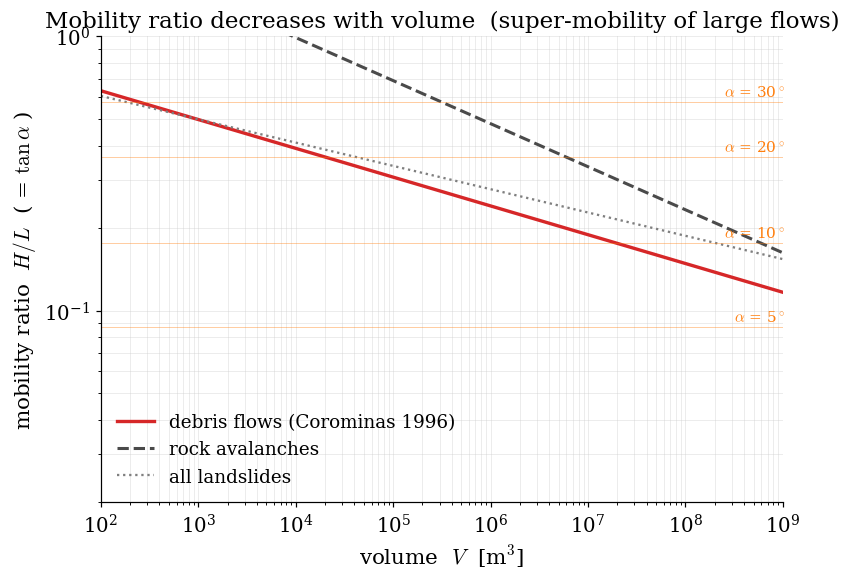

In [9]:
def mobility_ratio(V, a=-0.105, b=0.012):
    """Corominas (1996) H/L for debris flows, with V in m^3."""
    return 10**(a * np.log10(V) + b)


# Compute fahrböschung angle alpha = atan(H/L)
V_grid = np.logspace(2, 9, 200)
HL_debris  = mobility_ratio(V_grid, a=-0.105, b=0.012)
HL_rock_av = mobility_ratio(V_grid, a=-0.157, b=0.624)
HL_all     = mobility_ratio(V_grid, a=-0.085, b=-0.047)

fig, ax = plt.subplots(figsize=(8.0, 5.5))
ax.loglog(V_grid, HL_debris,  color=COLORS["fail"],    lw=2.2, label="debris flows (Corominas 1996)")
ax.loglog(V_grid, HL_rock_av, color=COLORS["rock"],    lw=2.0, ls="--", label="rock avalanches")
ax.loglog(V_grid, HL_all,     color=COLORS["neutral"], lw=1.5, ls=":",  label="all landslides")

# Mark a few representative alpha angles
for alpha_deg in [5, 10, 20, 30]:
    HL_val = np.tan(np.radians(alpha_deg))
    ax.axhline(HL_val, color=COLORS["accent"], lw=0.5, alpha=0.5)
    ax.text(1.05e9, HL_val * 1.05, fr"$\alpha$ = {alpha_deg}$^\circ$",
            fontsize=10, color=COLORS["accent"], ha="right")

ax.set_xlabel(r"volume  $V$  [m$^3$]")
ax.set_ylabel(r"mobility ratio  $H/L$  ( = $\tan\alpha$ )")
ax.set_title("Mobility ratio decreases with volume  (super-mobility of large flows)")
ax.set_xlim(1e2, 1e9); ax.set_ylim(0.02, 1.0)
ax.legend(loc="lower left")
ax.grid(True, which="both", alpha=0.4)
save_figure(fig, "debris_flow_mobility")
plt.show()


## 4. α–β analysis on a Tatra channel profile

A useful intermediate between the volume-runout scatter plot (too generic for a specific catchment) and a full Voellmy simulation (too parameter-hungry for a regional study) is the **α–β method** applied to a longitudinal channel profile:

- $\beta$ is the angle from the source to the **fan apex** (the topographic break where the channel widens and the slope flattens).
- $\alpha$ is the angle from the source to the **deposit toe** (the actual stopping point).

For Norwegian snow avalanches, Lied & Bakkehøi (1980) established the regression $\alpha = 0.96\,\beta - 1.4^\circ$. For European debris flows (Rickenmann 1999 and others), a comparable relation is $\alpha \approx 0.88\,\beta - 0.3^\circ$ — the flow runs about 12 % further than the fan-apex angle, on average.

For a given catchment, the workflow is:

1. Extract the longitudinal channel profile from a DEM.
2. Identify the source and the fan apex; compute $\beta$.
3. Predict $\alpha$ from the regression.
4. Draw the α-line from the source; its intersection with the channel profile gives the predicted deposit toe.


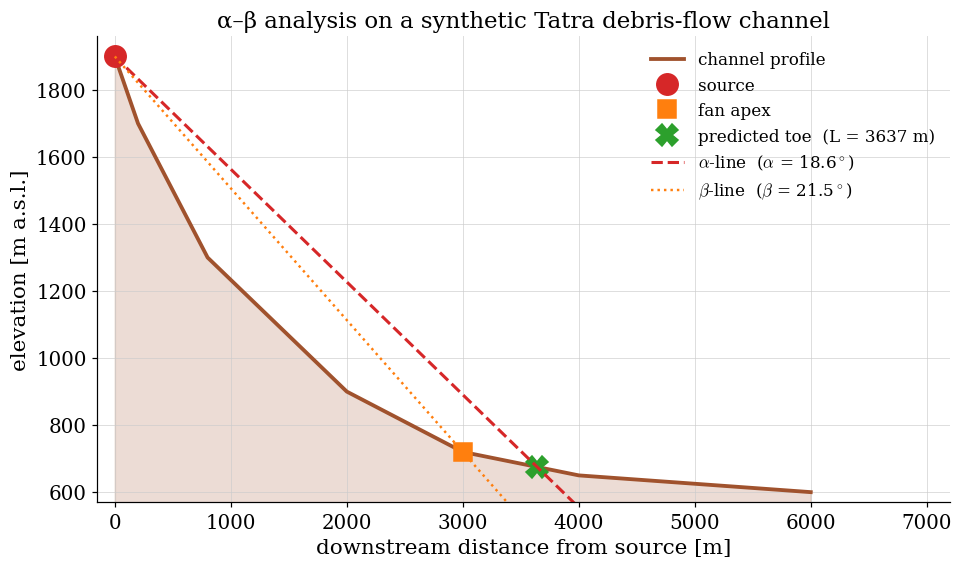

Beta (source -> fan apex): 21.47 deg
Predicted alpha:           18.59 deg
Predicted runout L:        3637 m


In [10]:
# Synthetic longitudinal profile of a Tatra debris-flow channel:
# source in alpine cirque -> steep gorge -> transport channel -> fan -> valley floor.
channel_x = np.array([    0.0,   200.0,   800.0,  2000.0,  3000.0,  4000.0,  6000.0])
channel_y = np.array([ 1900.0,  1700.0,  1300.0,   900.0,   720.0,   650.0,   600.0])

source_x, source_y = 0.0, 1900.0
fan_apex_x = 3000.0  # break in slope where channel widens onto the fan
fan_apex_y = float(np.interp(fan_apex_x, channel_x, channel_y))

# Beta angle: source to fan apex
H_to_apex = source_y - fan_apex_y
beta_deg = np.degrees(np.arctan2(H_to_apex, fan_apex_x))

# Predicted alpha from the debris-flow regression
alpha_deg = 0.88 * beta_deg - 0.3

# Draw alpha line and find intersection with channel profile
x_grid = np.linspace(0, channel_x[-1] + 1500, 300)
y_alpha_line = source_y - x_grid * np.tan(np.radians(alpha_deg))
y_channel_interp = np.interp(x_grid, channel_x, channel_y)

# Intersection (first x where alpha line drops below channel)
diff = y_alpha_line - y_channel_interp
crossings = np.where(np.diff(np.sign(diff)))[0]
L_predicted = x_grid[crossings[-1]] if len(crossings) > 1 else x_grid[-1]

# Beta line for reference
y_beta_line = source_y - x_grid * np.tan(np.radians(beta_deg))

fig, ax = plt.subplots(figsize=(10.0, 5.5))
ax.fill_between(channel_x, channel_y, channel_y.min() - 50,
                color=COLORS["soil"], alpha=0.20)
ax.plot(channel_x, channel_y, color=COLORS["soil"], lw=2.5, label="channel profile")

ax.plot([source_x], [source_y], "o", ms=14, color=COLORS["fail"], label="source")
ax.plot([fan_apex_x], [fan_apex_y], "s", ms=12, color=COLORS["accent"], label="fan apex")
ax.plot([L_predicted], [np.interp(L_predicted, channel_x, channel_y)],
        "X", ms=14, color=COLORS["safe"], label=f"predicted toe  (L = {L_predicted:.0f} m)")

ax.plot(x_grid, y_alpha_line, color=COLORS["fail"], lw=2.0, ls="--",
        label=fr"$\alpha$-line  ($\alpha$ = {alpha_deg:.1f}$^\circ$)")
ax.plot(x_grid, y_beta_line, color=COLORS["accent"], lw=1.6, ls=":",
        label=fr"$\beta$-line  ($\beta$ = {beta_deg:.1f}$^\circ$)")

ax.set_xlim(-150, channel_x[-1] + 1200)
ax.set_ylim(channel_y.min() - 30, source_y + 60)
ax.set_xlabel("downstream distance from source [m]")
ax.set_ylabel("elevation [m a.s.l.]")
ax.set_title("α–β analysis on a synthetic Tatra debris-flow channel")
ax.legend(loc="upper right", fontsize=11)
save_figure(fig, "tatra_channel_profile")
plt.show()

print(f"Beta (source -> fan apex): {beta_deg:.2f} deg")
print(f"Predicted alpha:           {alpha_deg:.2f} deg")
print(f"Predicted runout L:        {L_predicted:.0f} m")


## 5. Monte Carlo runout for an uncertain initiation volume

A single deterministic runout estimate underplays the central uncertainty in a real hazard assessment: we usually do not know the initiation volume to better than half an order of magnitude. The pragmatic approach is again Monte-Carlo:

1. Draw $V \sim \text{LogNormal}(\mu_V, \sigma_V)$ — typically $\sigma_{\log V}$ ≈ 0.3 captures a "factor of two" uncertainty.
2. For each draw, compute $L = k\,V^{1/3}\,10^{\,\epsilon}$ where $\epsilon \sim \mathcal{N}(0, \sigma_L)$ is the regression residual ($\sigma_L$ ≈ 0.2 from published compilations).
3. Histogram the resulting $L$ values; read off the P95 / P99 distances for hazard-zone boundaries.

Below we assume a most-likely initiation volume of $5 \times 10^4$ m³ (a moderate Tatra event) with factor-of-two uncertainty, and a mobility coefficient $k = 50$.


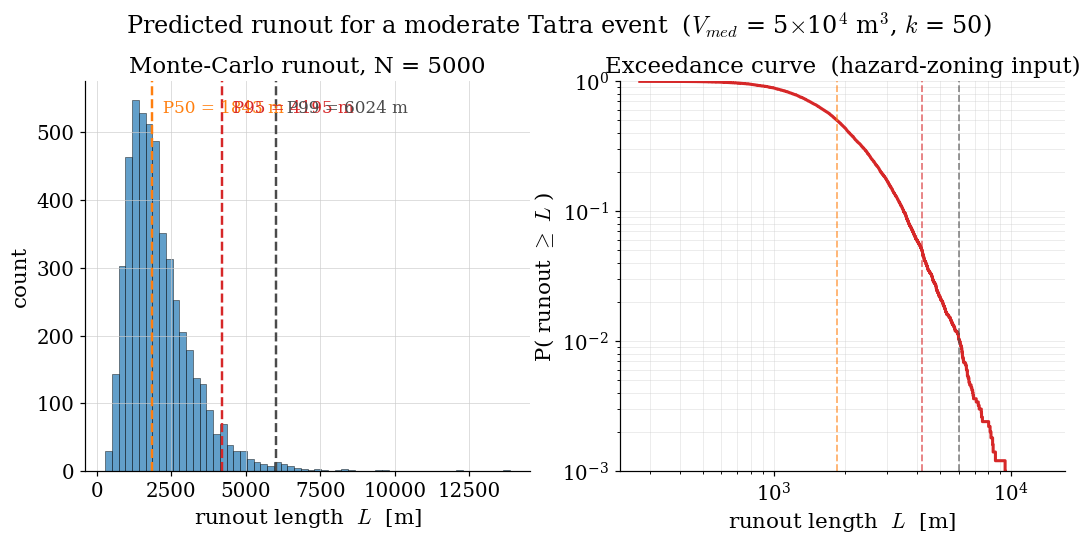

Median runout (P50): 1843 m
P95 (orange zone):    4195 m
P99 (red zone):       6024 m


In [11]:
# Monte Carlo runout for a moderate Tatra event
N_mc = 5000
V_mean_log10  = np.log10(5e4)   # median initiation volume
V_sigma_log10 = 0.3              # factor-of-two uncertainty
L_sigma_log10 = 0.20             # regression residual
k_mean = 50.0

V_samples = 10**np.random.normal(V_mean_log10, V_sigma_log10, N_mc)
L_samples = k_mean * V_samples**(1.0/3.0) * 10**np.random.normal(0.0, L_sigma_log10, N_mc)

P50 = np.percentile(L_samples, 50)
P95 = np.percentile(L_samples, 95)
P99 = np.percentile(L_samples, 99)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))

# Histogram
ax1.hist(L_samples, bins=60, color=COLORS["water"], alpha=0.7, edgecolor="black", linewidth=0.4)
for q_lab, q_val, q_col in [("P50", P50, COLORS["accent"]),
                            ("P95", P95, COLORS["fail"]),
                            ("P99", P99, COLORS["rock"])]:
    ax1.axvline(q_val, color=q_col, lw=1.6, ls="--")
    ax1.text(q_val, ax1.get_ylim()[1]*0.92, fr"  {q_lab} = {q_val:.0f} m",
             color=q_col, fontsize=11)
ax1.set_xlabel("runout length  $L$  [m]")
ax1.set_ylabel("count")
ax1.set_title(f"Monte-Carlo runout, N = {N_mc}")

# Empirical exceedance
sorted_L = np.sort(L_samples)
exceed = 1.0 - np.arange(N_mc) / N_mc
ax2.step(sorted_L, exceed, where="post", color=COLORS["fail"], lw=2.0)
ax2.set_yscale("log"); ax2.set_xscale("log")
ax2.set_xlabel("runout length  $L$  [m]")
ax2.set_ylabel(r"P( runout $\geq$ $L$ )")
ax2.set_title("Exceedance curve  (hazard-zoning input)")
for q_val, q_col in [(P50, COLORS["accent"]), (P95, COLORS["fail"]), (P99, COLORS["rock"])]:
    ax2.axvline(q_val, color=q_col, lw=1.2, ls="--", alpha=0.6)
ax2.grid(True, which="both", alpha=0.4)
ax2.set_ylim(1e-3, 1.0)

fig.suptitle(fr"Predicted runout for a moderate Tatra event  ($V_{{med}}$ = 5$\times$10$^4$ m$^3$, $k$ = {k_mean:.0f})", y=1.02)
save_figure(fig, "runout_distribution")
plt.show()

print(f"Median runout (P50): {P50:.0f} m")
print(f"P95 (orange zone):    {P95:.0f} m")
print(f"P99 (red zone):       {P99:.0f} m")


## 6. Interactive: design-event sensitivity

The two parameters that matter most are the median initiation volume and the mobility coefficient $k$. Try the controls below and notice:

- A factor-of-10 change in $V$ moves the median runout by $\sqrt[3]{10}$ ≈ 2.15× (the $V^{1/3}$ scaling).
- A factor-of-2 change in $k$ moves the median runout by exactly 2× (linear in $k$).
- The P99 / P50 ratio depends entirely on the residual scatter $\sigma_L$, not on the central values — so calibrating it requires a *local* dataset, not a generic value.


In [12]:
def explore_runout(V_log10=4.7, sigma_V=0.30, k=50.0, sigma_L=0.20):
    N_mc = 4000
    V_samples = 10**np.random.normal(V_log10, sigma_V, N_mc)
    L_samples = k * V_samples**(1.0/3.0) * 10**np.random.normal(0.0, sigma_L, N_mc)
    P50, P95, P99 = (np.percentile(L_samples, p) for p in (50, 95, 99))

    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.hist(L_samples, bins=50, color=COLORS["water"], alpha=0.75,
            edgecolor="black", linewidth=0.3)
    for lab, val, col in [("P50", P50, COLORS["accent"]),
                          ("P95", P95, COLORS["fail"]),
                          ("P99", P99, COLORS["rock"])]:
        ax.axvline(val, color=col, lw=1.5, ls="--")
        ax.text(val, ax.get_ylim()[1] * 0.92, fr"  {lab} = {val:.0f} m",
                color=col, fontsize=11)
    ax.set_xlabel("runout length  $L$  [m]")
    ax.set_ylabel("count")
    ax.set_title(fr"V = $10^{{{V_log10:.1f}}}$ m$^3$, k = {k:.0f}, "
                 fr"$\sigma_V$ = {sigma_V:.2f}, $\sigma_L$ = {sigma_L:.2f}")
    plt.show()


interact(
    explore_runout,
    V_log10=FloatSlider(min=2.0, max=7.0, step=0.1, value=4.7, description="log10 V"),
    sigma_V=FloatSlider(min=0.05, max=0.6, step=0.05, value=0.30, description=r"$\sigma_V$"),
    k      =FloatSlider(min=15.0, max=130.0, step=5.0, value=50.0, description="k"),
    sigma_L=FloatSlider(min=0.05, max=0.4, step=0.02, value=0.20, description=r"$\sigma_L$"),
);


interactive(children=(FloatSlider(value=4.7, description='log10 V', max=7.0, min=2.0), FloatSlider(value=0.3, …

## 7. Beyond empirical: where dynamic models are needed

The empirical scaling laws above answer the question *"how far does a debris flow of volume V travel?"* They do not answer:

- **How fast** is it moving at the fan apex? (Required for impact-force calculations on bridges and buildings.)
- **How wide** is the inundation across the fan? (Required to delineate hazard zones laterally, not just longitudinally.)
- **What is the flow depth** at any point in the channel? (Required to design check dams, deflection berms, and sediment-retention basins.)

These need a **dynamic model** — typically a depth-averaged solver of the Saint-Venant equations on a 2-D DEM, with a rheology that captures the granular-fluid behaviour of debris-flow material. The two most-cited models in European practice:

- **RAMMS::Debrisflow** (WSL, Switzerland): a Voellmy rheology, $\tau = \mu\sigma + \rho g u^2 / \xi$, calibrated against several hundred Alpine events. Easy interface; widely used for road-design hazard mapping.
- **FLO-2D** (USA): an O'Brien–Julien rheology distinguishing viscous, yield-stress, and turbulent regimes. More physics, more parameters, slower to set up.

Both reproduce $V^{1/3}$ scaling on synthetic test cases, which is reassuring — the empirical laws are not arbitrary.

> *Honest assessment for teaching.* For a doctoral student joining a debris-flow research group, the empirical methods in this notebook should be their first-week toolkit. Dynamic models become necessary only when (a) the topography is genuinely complex (lateral spreading, channel bifurcation), or (b) the deliverable requires velocity or depth, not just runout.


## Take-aways

- Debris-flow runout scales as $L \propto V^{1/3}$ across seven orders of magnitude in volume, with a mobility coefficient $k$ ≈ 30–80 for typical mountain debris flows.
- The mobility ratio $H/L$ decreases with volume (Corominas law). Big flows go further per unit elevation drop than small ones do.
- The α–β method on a longitudinal channel profile gives a defensible runout estimate from two angles measured on a DEM, with no calibration required beyond the regression constants.
- Monte Carlo over $V$ and the regression residual converts the central estimate into a probability-of-exceedance curve, from which hazard-zone boundaries are read at fixed quantiles.
- Empirical methods answer "how far"; dynamic models answer "how fast, how deep, how wide". Use the simplest tool that actually answers your question.


## Voluntary exercises

1. State the volume-runout scaling law for debris flows and explain its $V^{1/3}$ physical origin. By what factor does $L$ change if $V$ is doubled?
2. Using $L = 50\,V^{1/3}$, estimate the runout for a small Tatra event ($V = 10^3$ m³), a moderate event ($V = 5 \times 10^4$ m³), and a large event ($V = 10^6$ m³). Are these distances consistent with the lengths of real Tatra debris-flow fans?
3. Explain the "super-mobility of large flows" in your own words. What practical implication does it have for hazard maps calibrated against small historical events?
4. A village sits 1.8 km from a debris-flow source at the head of a Carpathian gully. Source elevation is 1500 m a.s.l.; village elevation is 600 m a.s.l. Using the Corominas mobility law for debris flows, what volume of event would be required to reach the village?


## References

- Iverson, R. M. (1997). *The physics of debris flows.* Reviews of Geophysics, 35(3), 245–296.
- Iverson, R. M., Schilling, S. P., & Vallance, J. W. (1998). *Objective delineation of lahar-inundation hazard zones.* GSA Bulletin, 110(8), 972–984.
- Corominas, J. (1996). *The angle of reach as a mobility index for small and large landslides.* Canadian Geotechnical Journal, 33(2), 260–271.
- Rickenmann, D. (1999). *Empirical relationships for debris flows.* Natural Hazards, 19(1), 47–77.
- Lied, K. & Bakkehøi, S. (1980). *Empirical calculations of snow-avalanche run-out distance based on topographic parameters.* Journal of Glaciology, 26(94), 165–177.
- Hungr, O., McDougall, S., & Bovis, M. (2005). *Entrainment of material by debris flows.* In *Debris-Flow Hazards and Related Phenomena*, Springer, 135–158.
- WSL RAMMS::Debrisflow user manual. https://ramms.slf.ch
- Jonasson, C., Kot, M., & Kotarba, A. (1991). *Lichenometrical studies and dating of debris-flow deposits in the High Tatra Mountains, Poland.* Geografiska Annaler A, 73(3–4), 141–146.
